In [1]:
#!pip install torch
#!pip install scikit-learn
#!pip install torchvision

# Bazni CNN model za klasifikaciju
- Treniranje konvolutivne neuronska mreža (CNN) koja slike znakova ruku klasifikuje direktno u odgovarajuće slovo znakovnog jezika (24 klase, bez J i Z jer zahtevaju pokret ruke kroz)
- Ovaj model predstavlja polazni rezultat sa kojim ćemo kasnije porediti model dobijen metric learning pristupom (triplet loss + KNN nad naučenim reprezentacijama)
- Ne radi se ponovo učitavanje sirovog CSV-a niti preprocesiranje, već su ulazni podaci dobijeni iz 02_priprema_podataka.ipynb

## Pretpostavke o izlazu iz 02_priprema_podataka.ipynb

- 02_priprema_podataka.ipynb čuva pripremljene podatke na disk
- Putanja fajla: data/processed/sign_mnist_prepared.npz
- Oblik piksela: (N, 28, 28)
- Tip i opseg piksela: float32, normalizovano [0, 1]
- Tip labela: int64, originalne oznake labela (0-8, 10-24; bez 9 i 25, jer J/Z ne postoje u datasetu)
- Podela stratifikovana val=15% trening skupa, seed=42

In [1]:
import json
import sys
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sys.path.insert(0, str(Path.cwd()))
from data_utils import (
    build_datasets,
    LABEL_TO_LETTER,
    NUM_CLASSES,
    BATCH_SIZE,
    SEED,
)
# Podešavanja izgleda grafika (rezolucija i veličina fonta) za sve grafike u notebook-u
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

# Konstante 

In [2]:
RESULTS_DIR = Path("../results/CNN model") 
RESULTS_DIR.mkdir(exist_ok=True)

EPOCHS = 30 
LEARNING_RATE = 1e-3
PATIENCE = 3  # broj epoha bez poboljšanja pre ranog zaustavljanja

# Uređaj na kom će se model i podaci obrađivati - GPU (cuda) ako je dostupan (brže treniranje), inače CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uređaj: {DEVICE}")

# Mapiranje labela u indekse (opseg 0..23) i obruto (indeksi u labele) jer mreža na izlazu ima NUM_CLASSES=24 neurona, a ne postoje labele 9 i 25
SORTED_LABELS = sorted(LABEL_TO_LETTER.keys())
LABEL_TO_IDX = {label: idx for idx, label in enumerate(SORTED_LABELS)}
IDX_TO_LABEL = {idx: label for label, idx in LABEL_TO_IDX.items()}

def remap_labels(labels):
    return np.array([LABEL_TO_IDX[int(l)] for l in labels], dtype=np.int64)

Uređaj: cpu


## Fiksiranje vrednosti seed
- fiksira se pomoću seed-a random vrednosti, jer bi pri svakom pokretanju vrednosti bile drugačije, što će da oteža i poređenje modela

In [3]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Seed fiksiran na {SEED}")

Seed fiksiran na 42


## Učitavanje pripremljenih podataka 
- koristi se build_datasets() iz data_utils.py, koja učitava .npz i pravi SignMnistDataset objekte

In [4]:
train_ds, val_ds, test_ds = build_datasets(with_augmentation=True)

print(f"Train: {len(train_ds)} primera")
print(f"Val:   {len(val_ds)} primera")
print(f"Test:  {len(test_ds)} primera")

Train: 23336 primera
Val:   4119 primera
Test:  7172 primera


## Pravljenje DataLoader-a

In [5]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch slika: {images.shape}, dtype={images.dtype}")
print(f"Batch oznaka: {labels.shape}, dtype={labels.dtype}")
print(f"Opseg piksela u batch-u: [{images.min():.3f}, {images.max():.3f}]")

Batch slika: torch.Size([64, 1, 28, 28]), dtype=torch.float32
Batch oznaka: torch.Size([64]), dtype=torch.int64
Opseg piksela u batch-u: [0.000, 1.000]


## Vizuelna provera
Par (6) slika iz trening skupa (sa augmentacijom) kako bismo se uverili da su podaci ispravno učitani

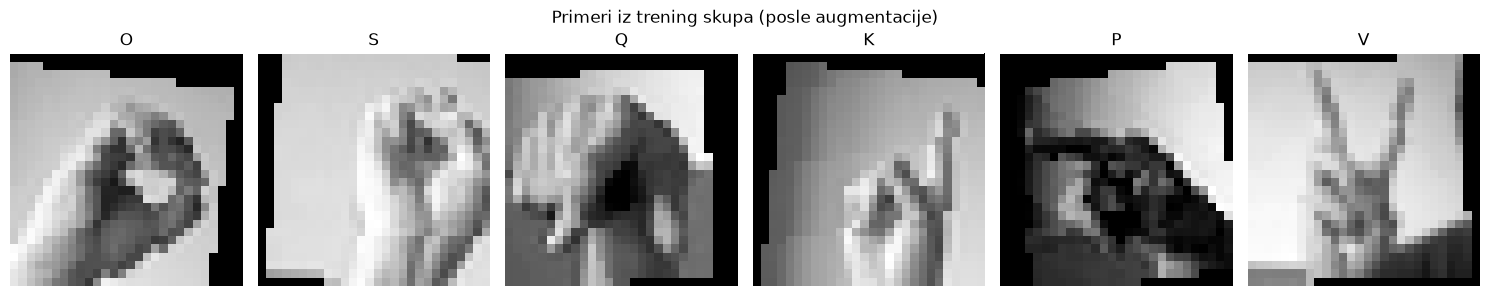

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    img, label = train_ds[i]
    axes[i].imshow(img.squeeze(0), cmap="gray")
    axes[i].set_title(LABEL_TO_LETTER[label])
    axes[i].axis("off")
plt.suptitle("Primeri iz trening skupa (posle augmentacije)")
plt.tight_layout()
plt.show()

## Arhitektura CNN modela

Mreža ima dva dela: 
- features: iz slike izvlači karakteristike slike
- classifier: na osnovu tih karakteristika odlučuje koje je slovo u pitanju.

**features** je organizovan u tri bloka, svaki sledeći blok ima više filtera (32 -> 64 -> 128). Početni slojevi hvataju jednostavne stvari (ivice, konture prstiju), a dublji slojevi kombinuju to u složenije obrasce (oblik šake, položaj prstiju). Svaki blok ima:
- dva konvolutivna sloja + batch normalizaciju (stabilizuje treniranje) + ReLU aktivacionu funkciju
- MaxPool2d na kraju bloka, koji upola smanjuje dimenzije slike (28 -> 14 -> 7 -> 3)
- Dropout da se mreža ne oslanja previše na pojedinačne neurone (sprečava overfitting)

**classifier** zatim spljošti (Flatten) izlaz iz poslednjeg bloka u jedan vektor, propusti ga kroz potpuno povezani sloj od 256 neurona, i na kraju kroz izlazni sloj sa NUM_CLASSES=24 neurona - po jedan za svako slovo koje mreža treba da prepozna.

In [7]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )

        # 28 -> 14 -> 7 -> 3 (posle tri MaxPool2d(2), floor deljenje)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = BaselineCNN().to(DEVICE)

## Pomoćna funkcija za jednu epohu treniranja/evaluacije
- ista funkcija se koristi i za trening i validaciju
- kada je prosleđen optimizer radimo trening modela, a ako nije prosleđen radimo validaciju modela

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(DEVICE)
            labels_idx = torch.tensor(remap_labels(labels.numpy())).to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_idx)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels_idx).sum().item()
            total_samples += images.size(0)
    return total_loss / total_samples, total_correct / total_samples

## Trening petlja
- optimizator: Adam
- criterion/loss funkcija: CrossEntropyLoss
- ReduceLROnPlateau za smanjenje learning rate-a ako val_loss ne opada PATIENCE (definisano na početku) epohe zaredom
- history: rečnik u koji se posle svake epohe upisuju loss i tačnost za trening i validaciju 

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=PATIENCE
)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_loss = float("inf")
epochs_without_improvement = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoha {epoch:2d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Rano zaustavljanje posle {epoch} epoha (bez poboljšanja {PATIENCE} epoha).")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Učitane najbolje težine (najmanji val_loss).")

Epoha  1/30 | train_loss=1.1489 train_acc=0.6629 | val_loss=0.1854 val_acc=0.9553
Epoha  2/30 | train_loss=0.2325 train_acc=0.9343 | val_loss=0.0191 val_acc=0.9990
Epoha  3/30 | train_loss=0.1127 train_acc=0.9678 | val_loss=0.0042 val_acc=1.0000
Epoha  4/30 | train_loss=0.0798 train_acc=0.9768 | val_loss=0.0030 val_acc=0.9998
Epoha  5/30 | train_loss=0.0637 train_acc=0.9798 | val_loss=0.0068 val_acc=0.9985
Epoha  6/30 | train_loss=0.0470 train_acc=0.9855 | val_loss=0.0018 val_acc=1.0000
Epoha  7/30 | train_loss=0.0445 train_acc=0.9863 | val_loss=0.0005 val_acc=1.0000
Epoha  8/30 | train_loss=0.0413 train_acc=0.9872 | val_loss=0.0032 val_acc=0.9993
Epoha  9/30 | train_loss=0.0320 train_acc=0.9898 | val_loss=0.0003 val_acc=1.0000
Epoha 10/30 | train_loss=0.0326 train_acc=0.9896 | val_loss=0.0040 val_acc=0.9985
Epoha 11/30 | train_loss=0.0314 train_acc=0.9901 | val_loss=0.0002 val_acc=1.0000
Epoha 12/30 | train_loss=0.0288 train_acc=0.9904 | val_loss=0.0013 val_acc=0.9993
Rano zaustavljan

## Grafik treniranja modela

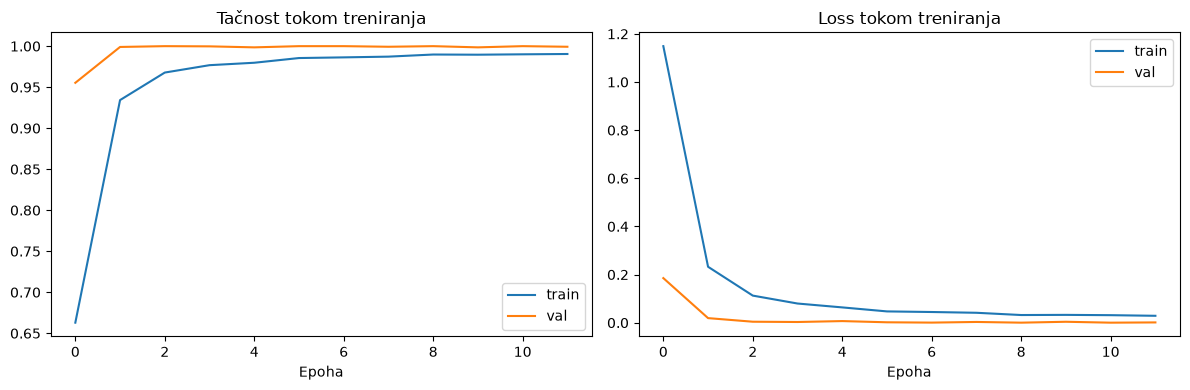

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_acc"], label="train")
axes[0].plot(history["val_acc"], label="val")
axes[0].set_title("Tačnost tokom treniranja")
axes[0].set_xlabel("Epoha")
axes[0].legend()

axes[1].plot(history["train_loss"], label="train")
axes[1].plot(history["val_loss"], label="val")
axes[1].set_title("Loss tokom treniranja")
axes[1].set_xlabel("Epoha")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_training_curves.png", dpi=150)
plt.show()

## Evaluacija na test skupu
- test skup se koristi samo ovde, nije bio poznat tokom treniranja niti biranja parametara modela

In [18]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds_idx = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend([IDX_TO_LABEL[p] for p in preds_idx])
        all_true.extend(labels.numpy().tolist())

all_true = np.array(all_true)
all_preds = np.array(all_preds)

acc = accuracy_score(all_true, all_preds)
print(f"Tačnost na test skupu: {acc:.4f}")

Tačnost na test skupu: 0.9997


## Izveštaj po klasama (classification report)

Za svako slovo posebno se računaju tri metrike:
- **precision** - od svega što je model predvideo kao određeno slovo, koliki procenat je zaista bio to slovo
- **recall** - od svih pravih primera određenog slova, koliki procenat je model tačno prepoznao
- **f1-score** - kombinacija precision-a i recall-a u jedan broj

**suppor** pokazuje koliko primera određenog slova ima u test skupu (bitno jer metrika izračunata na svega par primera nije pouzdana koliko ona izračunata na stotinama primera).

Na dnu tabele:
- **accuracy** - ukupna tačnost preko svih primera (bez obzira na slovo)
- **macro avg** - prosek metrike preko svih slova, svako slovo ima jednaku težinu bez obzira na broj primera
- **weighted avg** - prosek gde slova sa više primera (veći support) imaju veći uticaj na prosek

In [19]:
target_names = [LABEL_TO_LETTER[l] for l in SORTED_LABELS]
report = classification_report(
    all_true, all_preds, labels=SORTED_LABELS,
    target_names=target_names, digits=3, zero_division=0,
)
print(report)

with open(RESULTS_DIR / "cnn_classification_report.txt", "w") as f:
    f.write(f"Test accuracy: {acc:.4f}\n\n{report}")

              precision    recall  f1-score   support

           A      1.000     1.000     1.000       331
           B      1.000     0.998     0.999       432
           C      1.000     1.000     1.000       310
           D      1.000     1.000     1.000       245
           E      1.000     0.998     0.999       498
           F      1.000     1.000     1.000       247
           G      1.000     1.000     1.000       348
           H      1.000     1.000     1.000       436
           I      1.000     1.000     1.000       288
           K      0.997     1.000     0.998       331
           L      1.000     1.000     1.000       209
           M      1.000     1.000     1.000       394
           N      1.000     1.000     1.000       291
           O      1.000     1.000     1.000       246
           P      1.000     1.000     1.000       347
           Q      1.000     1.000     1.000       164
           R      1.000     1.000     1.000       144
           S      0.996    

## Matrica konfuzije
- koja slova model najčešće meša (očekivano: vizuelno slična slova poput M/N/S)  
- y-osa = stvarno slovo na slici, x-osa = slovo koje je model predvideo
- Svako polje (x, y) pokazuje koliko je slika sa stvarnim slovom (y) model svrstao u predviđenu klasu (x)
- Dijagonala (gore levo -> dole desno) = tačna predviđanja - treba da bude najtamnija linija na mapi
- Tamno polje van dijagonale - model sistematski meša ta dva slova (npr. polje M/O znači da model često sliku M prepoznaje kao O)
- Colorbar sa desne strane pokazuje referencu koji broj primera odgovara kojoj nijansi boje

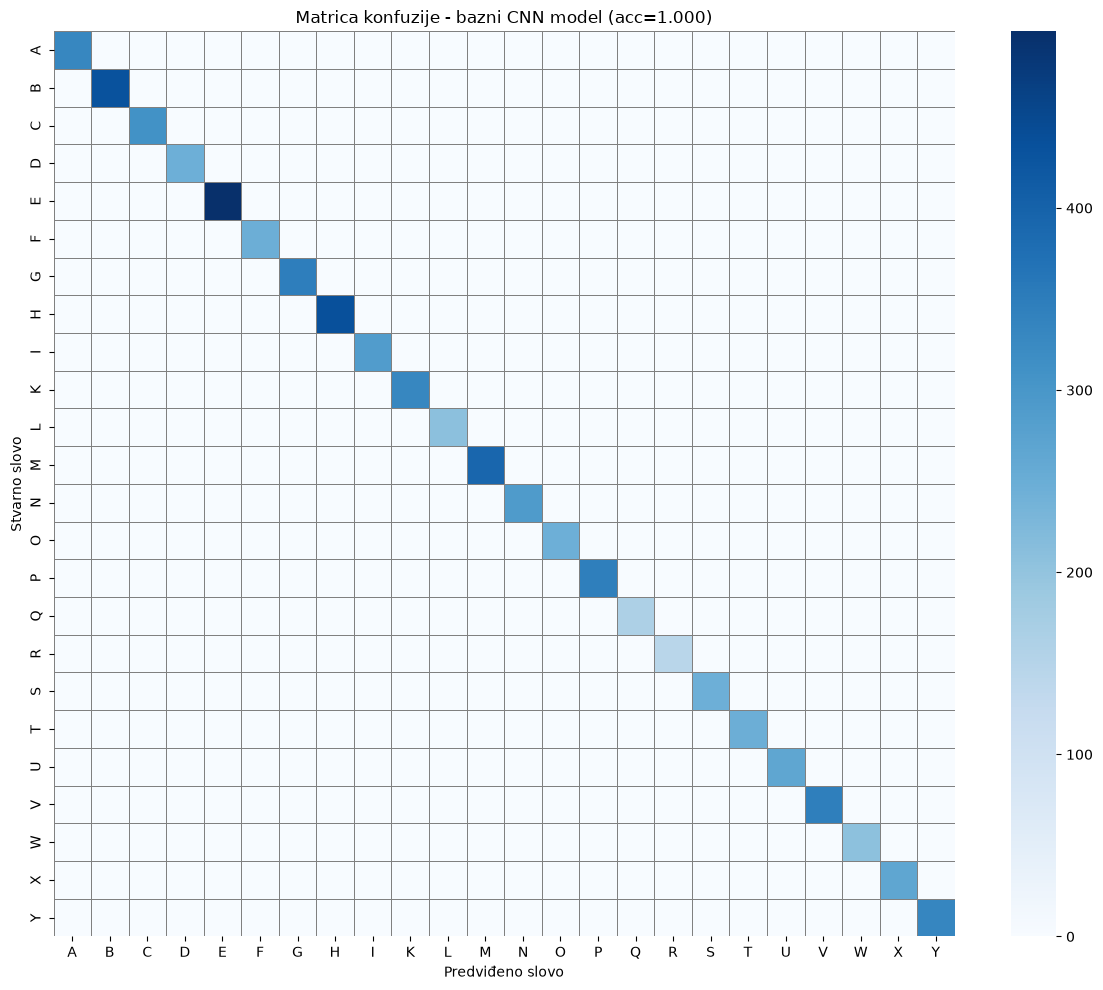

In [20]:
cm = confusion_matrix(all_true, all_preds, labels=SORTED_LABELS)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=target_names, yticklabels=target_names, linewidths=0.5, linecolor="gray")
plt.xlabel("Predviđeno slovo")
plt.ylabel("Stvarno slovo")
plt.title(f"Matrica konfuzije - bazni CNN model (acc={acc:.3f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_confusion_matrix.png", dpi=150)
plt.show()

## Čuvanje modela i rezultata
- rezultat (cnn_summary.json) služi za kasnije poređenje sa drugim modelom

In [21]:
model_path = RESULTS_DIR / "cnn_model.pt"
torch.save(model.state_dict(), model_path)
print(f"Model sačuvan: {model_path}")

summary = {
    "model": "baseline_cnn_pytorch",
    "test_accuracy": float(acc),
    "num_train_samples": len(train_ds),
    "num_val_samples": len(val_ds),
    "num_test_samples": len(test_ds),
    "epochs_ran": len(history["train_loss"]),
}
with open(RESULTS_DIR / "cnn_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

summary

Model sačuvan: ../results/CNN model/cnn_model.pt


{'model': 'baseline_cnn_pytorch',
 'test_accuracy': 0.9997211377579476,
 'num_train_samples': 23336,
 'num_val_samples': 4119,
 'num_test_samples': 7172,
 'epochs_ran': 12}